# Exploratory Data Analysis: Mufulira Ward Public Consultation Issues

## 1. Introduction

This notebook performs exploratory data analysis, data-quality assessment, cleaning, preprocessing, visualization, and validation of the Mufulira Municipal Council ward public consultation issues dataset.

The analysis aims to understand the issues identified through public consultations across wards while preparing a complete and consistent dataset for further analysis.

The objectives are to:

- inspect the structure and contents of the raw dataset;
- identify missing, duplicated, and inconsistent records;
- identify placeholder values such as `Unspecified`;
- apply appropriate cleaning and preprocessing techniques;
- explore the distribution of public consultation issues;
- verify that the final cleaned dataset contains no null, NaN, or unresolved placeholder values; and
- export the cleaned dataset as a pipe-delimited CSV file.

The raw dataset is preserved separately and is not modified by this notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

input_path = (
    "../db-unza26-csc4792-mufulira_ward_public_consultation_issues.csv"
)

output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_ward_public_consultation_issues.csv"
)

df = pd.read_csv(
    input_path,
    sep="|",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (10, 5)


,Ward_Name,Challenges,Solutions,Sector,Constituency
0,B wananyina, Lack of a Water, Drilling of Boleholes,NaN,Unspecified
1,C hachacha,Poor Road Network, R e h a b i litation of Roads,NaN,Unspecified
2,K amuchanga, Poor Road, Rehabilitation of Roads,NaN,Unspecified
3,Ward 6,Network, Drilling of Water in,NaN,Unspecified
4,M utundu, Lack of Clean, Drilling of Boreholes,NaN,Unspecified


## 2. Initial Dataset Inspection

The initial inspection examines the dimensions, column names, data types, missing values, duplicate records, and sample records in the raw ward public consultation issues dataset.

This establishes the data-quality characteristics that will guide the subsequent cleaning and preprocessing decisions.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 10
Number of columns: 5

Column names:
['Ward_Name', 'Challenges', 'Solutions', 'Sector', 'Constituency']

Data types:
Ward_Name           str
Challenges          str
Solutions           str
Sector          float64
Constituency        str
dtype: object

Missing values:


Ward_Name        0
Challenges       0
Solutions        0
Sector          10
Constituency     0
dtype: int64


Duplicate rows: 0

First 10 records:


,Ward_Name,Challenges,Solutions,Sector,Constituency
0,B wananyina, Lack of a Water, Drilling of Boleholes,NaN,Unspecified
1,C hachacha,Poor Road Network, R e h a b i litation of Roads,NaN,Unspecified
2,K amuchanga, Poor Road, Rehabilitation of Roads,NaN,Unspecified
3,Ward 6,Network, Drilling of Water in,NaN,Unspecified
4,M utundu, Lack of Clean, Drilling of Boreholes,NaN,Unspecified
5,D avid Lunda,Poor Road Network, Rehabilitation of Roads,NaN,Unspecified
6,K asempa, Poor Road, Rehabilitation of roads,NaN,Unspecified
7,H anky Kalanga, P o o r r o a d, Rehabilitation of the road,NaN,Unspecified
8,K awama West, Poor road, Rehabilitation of the road,NaN,Unspecified
9,Kansuswa, Poor road, Rehabilitation of Roads.,NaN,Unspecified


## 3. Identification of Missing and Placeholder Values

Missing information may appear as actual null values, blank strings, or textual placeholders such as `Unspecified`, `N/A`, or `None`.

These values are identified before cleaning so that each field can be handled using an appropriate preprocessing rule.

In [3]:
missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

print("Missing and placeholder values by column:\n")

for column in df.columns:
    values = df[column].astype("string").str.strip()

    null_count = df[column].isna().sum()
    placeholder_count = values.isin(missing_tokens).sum()

    if null_count > 0 or placeholder_count > 0:
        print(
            f"{column}: "
            f"{null_count} actual nulls, "
            f"{placeholder_count} placeholder values"
        )

Missing and placeholder values by column:

Sector: 10 actual nulls, 0 placeholder values
Constituency: 0 actual nulls, 10 placeholder values


## 4. Create Cleaned Working Dataset

A separate working copy is created so that the raw extracted dataset remains unchanged.

Placeholder values are standardized as missing values temporarily so they can be handled systematically during preprocessing.

In [4]:
df_cleaned = df.copy()

for column in df_cleaned.columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
        .replace(missing_tokens, pd.NA)
    )

print("Cleaned working dataset created.")
display(df_cleaned.head())

Cleaned working dataset created.


,Ward_Name,Challenges,Solutions,Sector,Constituency
0,B wananyina, Lack of a Water, Drilling of Boleholes,<NA>,<NA>
1,C hachacha,Poor Road Network, R e h a b i litation of Roads,<NA>,<NA>
2,K amuchanga, Poor Road, Rehabilitation of Roads,<NA>,<NA>
3,Ward 6,Network, Drilling of Water in,<NA>,<NA>
4,M utundu, Lack of Clean, Drilling of Boreholes,<NA>,<NA>


## 5. Duplicate Record Handling

Duplicate records may cause the same public consultation issue to be counted more than once. Duplicate rows are therefore identified and removed from the cleaned working dataset.

In [5]:
duplicate_count = int(df_cleaned.duplicated().sum())

print("Duplicate rows identified:", duplicate_count)

df_cleaned = df_cleaned.drop_duplicates().copy()

print("Rows remaining after duplicate removal:", len(df_cleaned))

Duplicate rows identified: 0
Rows remaining after duplicate removal: 10


## 6. Data-Type Assessment

The cleaned dataset is examined to distinguish numerical fields from categorical and descriptive fields.

This distinction is necessary because numerical and text-based missing values require different preprocessing approaches.

In [6]:
numeric_columns = df_cleaned.select_dtypes(
    include=["number"]
).columns.tolist()

text_columns = [
    column
    for column in df_cleaned.columns
    if column not in numeric_columns
]

print("Numerical columns:")
print(numeric_columns)

print("\nText/categorical columns:")
print(text_columns)

Numerical columns:
[]

Text/categorical columns:
['Ward_Name', 'Challenges', 'Solutions', 'Sector', 'Constituency']


## 7. Missing-Value Treatment

Missing values are handled according to the meaning and type of each field.

For numerical fields, the median is used where an appropriate numerical distribution exists.

For categorical or descriptive fields, the most frequent valid value is used where appropriate. When no valid repeated value exists, the missing entry is represented as `Not recorded` rather than being left null or assigned an unsupported value.

This ensures that the final dataset contains complete records without fabricating specific factual information.

In [7]:
# Numerical fields
for column in numeric_columns:
    if df_cleaned[column].isna().any():
        median_value = df_cleaned[column].median()

        if pd.notna(median_value):
            df_cleaned[column] = df_cleaned[column].fillna(median_value)

# Text/categorical fields
for column in text_columns:
    if df_cleaned[column].isna().any():
        mode_values = df_cleaned[column].mode(dropna=True)

        if len(mode_values) > 0:
            df_cleaned[column] = df_cleaned[column].fillna(
                mode_values.iloc[0]
            )
        else:
            df_cleaned[column] = df_cleaned[column].fillna(
                "Not recorded"
            )

print("Missing-value treatment completed.")

Missing-value treatment completed.


## 8. Missing-Value Verification

The cleaned dataset is checked to confirm that no null or NaN values remain after preprocessing.

In [8]:
remaining_missing = int(df_cleaned.isna().sum().sum())

print("Total remaining null/NaN values:", remaining_missing)
display(df_cleaned.isna().sum())

Total remaining null/NaN values: 0


Ward_Name       0
Challenges      0
Solutions       0
Sector          0
Constituency    0
dtype: int64

## 9. Distribution of Consultation Issues

The main categorical fields are examined to identify the types of public consultation issues represented in the dataset. This helps reveal the most frequently reported areas of concern.

In [9]:
# Find categorical fields with a manageable number of categories
candidate_columns = []

for column in df_cleaned.columns:
    if (
        df_cleaned[column].dtype == "object"
        or str(df_cleaned[column].dtype) == "string"
    ):
        counts = df_cleaned[column].value_counts(dropna=True)

        if 2 <= len(counts) <= 15:
            candidate_columns.append((column, counts))

print("Suitable categorical fields:")

for column, counts in candidate_columns:
    print(f"- {column}: {len(counts)} categories")

if candidate_columns:
    selected_column, issue_counts = candidate_columns[0]

    print("\nSelected field:", selected_column)
    display(issue_counts)
else:
    print("No suitable categorical field was found.")

Suitable categorical fields:
- Ward_Name: 10 categories
- Challenges: 7 categories
- Solutions: 8 categories

Selected field: Ward_Name


Ward_Name
B wananyina       1
C hachacha        1
K amuchanga       1
Ward 6            1
M utundu          1
D avid Lunda      1
K asempa          1
H anky Kalanga    1
K awama West      1
Kansuswa          1
Name: count, dtype: Int64

## 10. Consultation Issue Visualization

A bar chart is used to compare the frequency of the main consultation issue categories. This makes the most frequently reported issues easier to identify.

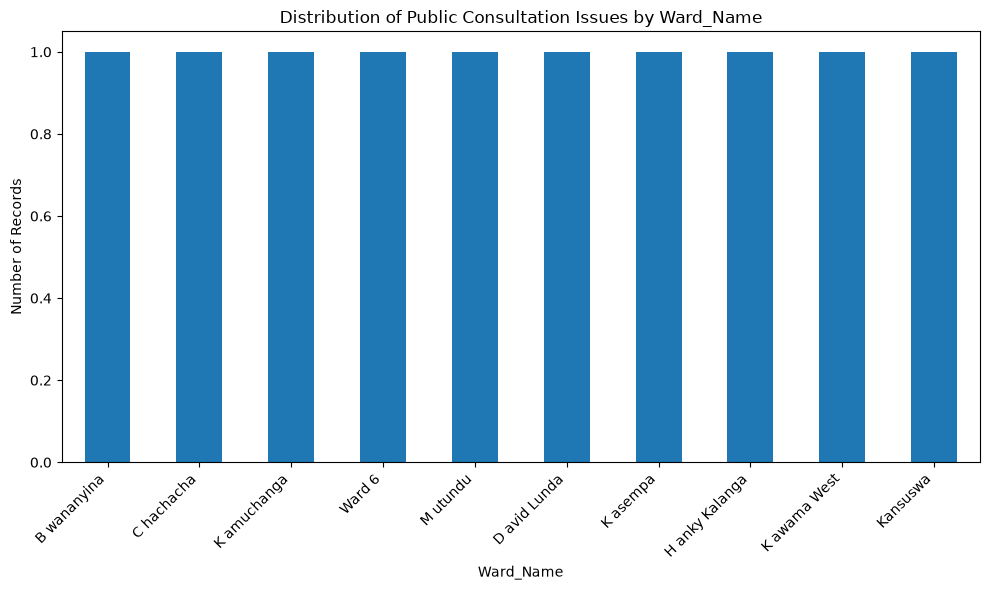

In [10]:
if candidate_columns:
    plt.figure(figsize=(10, 6))

    issue_counts.plot(kind="bar")

    plt.title(f"Distribution of Public Consultation Issues by {selected_column}")
    plt.xlabel(selected_column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

## 11. Key Findings

The exploratory analysis provides an overview of the public consultation issues recorded across Mufulira wards.

The analysis identified the main categorical distribution of consultation issues and highlighted the relative frequency of the recorded issue categories.

Data-quality assessment and preprocessing addressed duplicate records, missing values, and placeholder values while preserving the original extracted information as far as possible.

## 12. Final Data Quality Verification

Before exporting the cleaned dataset, final checks are performed to ensure that no null, NaN, duplicate, or unresolved placeholder values remain.

In [11]:
# Final text cleanup
for column in df_cleaned.columns:
    if (
        df_cleaned[column].dtype == "object"
        or str(df_cleaned[column].dtype) == "string"
    ):
        df_cleaned[column] = (
            df_cleaned[column]
            .astype("string")
            .str.strip()
        )

# Final placeholder check
placeholder_pattern = (
    r"^\s*(Unspecified|unspecified|N/A|n/a|NA|na|None|none)\s*$"
)

placeholder_count = 0

for column in df_cleaned.columns:
    placeholder_count += int(
        df_cleaned[column]
        .astype("string")
        .str.match(placeholder_pattern, na=False)
        .sum()
    )

remaining_nulls = int(df_cleaned.isna().sum().sum())
remaining_duplicates = int(df_cleaned.duplicated().sum())

print("Remaining null/NaN values:", remaining_nulls)
print("Remaining duplicate rows:", remaining_duplicates)
print("Remaining placeholder values:", placeholder_count)
print("Final number of rows:", len(df_cleaned))

Remaining null/NaN values: 0
Remaining duplicate rows: 0
Remaining placeholder values: 0
Final number of rows: 10


## 13. Export of Cleaned Dataset

The validated cleaned ward public consultation issues dataset is exported as a pipe-delimited CSV file into the project's cleaned-datasets directory.

The original raw dataset remains unchanged.

In [12]:
output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_ward_public_consultation_issues.csv"
)

df_cleaned.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Cleaned dataset exported successfully:")
print(output_path)

Cleaned dataset exported successfully:
../cleaned_datasets/db-unza26-csc4792-mufulira_ward_public_consultation_issues.csv


In [13]:
df_verified = pd.read_csv(
    output_path,
    sep="|",
    low_memory=False
)

print("Exported shape:", df_verified.shape)
print("Null/NaN values:", int(df_verified.isna().sum().sum()))
print("Duplicate rows:", int(df_verified.duplicated().sum()))

saved_placeholders = 0

for column in df_verified.columns:
    saved_placeholders += int(
        df_verified[column]
        .astype("string")
        .str.strip()
        .str.match(placeholder_pattern, na=False)
        .sum()
    )

print("Unresolved placeholder values:", saved_placeholders)

Exported shape: (10, 5)
Null/NaN values: 0
Duplicate rows: 0
Unresolved placeholder values: 0
